In [11]:
import os
import numpy as np
import pandas as pd
import librosa
from rich.table import Table
from rich.console import Console
import warnings
from multiprocessing import  cpu_count
from functools import partial

warnings.filterwarnings("ignore")
import multiprocess as mp
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from cachetools import cached

plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

In [12]:
BASE_DIR = "./Dataset"
LANGUAGES = ("German", "Italian", "Korean", "Spanish")


@cached(cache={})
def load_audio(file_path: str, sr=16000):
    signal, sample_rate = librosa.load(file_path, sr=sr)
    return signal, sample_rate


def load_df() -> pd.DataFrame:
    return_data = []
    for language in LANGUAGES:
        path = os.path.join(BASE_DIR, language)
        genders = os.listdir(path)
        for gender in genders:
            dir_path = os.path.join(path, gender)
            if not os.path.isdir(dir_path):
                continue
            audio_files = os.listdir(dir_path)
            for audio_file in audio_files:
                audio_path = os.path.join(dir_path, audio_file)
                return_data.append(
                    {
                        "language": language,
                        "gender": gender,
                        "audio_path": audio_path,
                    }
                )
    return pd.DataFrame(return_data)


@cached(cache={})
def get_mfccs(path: str, n_features=13):
    audio, sr = load_audio(path)
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_features)
    mfccs = np.mean(mfccs.T, axis=0)
    return mfccs


@cached(cache={})
def get_mel_spectrogram(path: str, n_features=128):
    audio, sr = load_audio(path)
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=n_features)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    mel_spec_db = np.mean(mel_spec_db.T, axis=0)
    return mel_spec_db

def run_parallel(func, paths, n_features):
    n_jobs = cpu_count() - 1
    if n_jobs < 1:
        n_jobs = 1
    with mp.Pool(processes=n_jobs) as pool:
        results = list(
            tqdm(
                pool.imap(partial(func, n_features=n_features), paths),
                total=len(paths),
                desc=f"Extracting features with {func.__name__}",
            )
        )
    results = [r for r in results if r is not None]
    return np.array(results)


df = load_df()
print(f"{df.shape = }")
print(df["language"].value_counts())

df.shape = (720, 3)
language
German     180
Italian    180
Korean     180
Spanish    180
Name: count, dtype: int64


In [13]:
audio_paths = df["audio_path"].tolist()
X_mfccs = run_parallel(get_mfccs, audio_paths, n_features=13)
X_mel_specs = run_parallel(get_mel_spectrogram, audio_paths, n_features=128)

X_combined = np.hstack([X_mfccs, X_mel_specs])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["language"])

print(f"{X_mfccs.shape = }")
print(f"{X_mel_specs.shape = }")
print(f"{X_combined.shape = }")
print(f"{y.shape = }")
print(
    f"label_encoder: {dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))}"
)

Extracting features with get_mel_spectrogram: 100%|██████████| 720/720 [00:09<00:00, 79.23it/s] 


X_mfccs.shape = (720, 13)
X_mel_specs.shape = (720, 128)
X_combined.shape = (720, 141)
y.shape = (720,)
label_encoder: {'German': np.int64(0), 'Italian': np.int64(1), 'Korean': np.int64(2), 'Spanish': np.int64(3)}


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"{X_train_scaled.shape = }")
print(f"{X_test_scaled.shape = }")
print("y_train")
print(pd.Series(y_train).value_counts())
print("y_test")
print(pd.Series(y_test).value_counts())

X_train_scaled.shape = (576, 141)
X_test_scaled.shape = (144, 141)
y_train
1    144
2    144
3    144
0    144
Name: count, dtype: int64
y_test
0    36
2    36
3    36
1    36
Name: count, dtype: int64


In [15]:
classifiers = {
    "KNN": KNeighborsClassifier(
        n_neighbors=5, weights="distance", metric="euclidean"
    ),
    "SVM": SVC(
        kernel="rbf", C=1.0, gamma="scale", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=20, random_state=42, n_jobs=-1
    ),
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
    ),
}

results = {}

In [16]:
table = Table(title="Classification Results", show_lines=True)
table.add_column("Classifier",  no_wrap=True)
table.add_column("Accuracy")
for name, clf in classifiers.items():

    clf.fit(X_train_scaled, y_train)

    y_pred = clf.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = {
        "classifier": clf,
        "predictions": y_pred,
        "accuracy": accuracy,
        "classification_report": classification_report(
            y_test, y_pred, target_names=label_encoder.classes_, output_dict=True
        ),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
    }

    table.add_row(name, f"{accuracy:.4f}")

console = Console()
console.print(table)

   Classification Results    
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Classifier     ┃ Accuracy ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ KNN            │ 0.9722   │
├────────────────┼──────────┤
│ SVM            │ 0.9861   │
├────────────────┼──────────┤
│ Random Forest  │ 0.9861   │
├────────────────┼──────────┤
│ Neural Network │ 0.9722   │
└────────────────┴──────────┘

In [17]:
# Display detailed metrics (F1, Precision, Recall - Weighted and Macro) for each classifier
from rich.table import Table
from rich.console import Console

console = Console()

# Create comprehensive metrics table
metrics_table = Table(title="Detailed Classification Metrics", show_lines=True)
metrics_table.add_column("Classifier", style="cyan", no_wrap=True)
metrics_table.add_column("Accuracy", justify="right", style="magenta")
metrics_table.add_column("Macro Precision", justify="right", style="green")
metrics_table.add_column("Macro Recall", justify="right", style="green")
metrics_table.add_column("Macro F1-Score", justify="right", style="green")
metrics_table.add_column("Weighted Precision", justify="right", style="yellow")
metrics_table.add_column("Weighted Recall", justify="right", style="yellow")
metrics_table.add_column("Weighted F1-Score", justify="right", style="yellow")

for name, result in results.items():
    report = result['classification_report']
    metrics_table.add_row(
        name,
        f"{result['accuracy']:.4f}",
        f"{report['macro avg']['precision']:.4f}",
        f"{report['macro avg']['recall']:.4f}",
        f"{report['macro avg']['f1-score']:.4f}",
        f"{report['weighted avg']['precision']:.4f}",
        f"{report['weighted avg']['recall']:.4f}",
        f"{report['weighted avg']['f1-score']:.4f}"
    )

console.print(metrics_table)

                                          Detailed Classification Metrics                                          
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃                ┃          ┃       Macro ┃       Macro ┃        Macro ┃    Weighted ┃     Weighted ┃    Weighted ┃
┃ Classifier     ┃ Accuracy ┃   Precision ┃      Recall ┃     F1-Score ┃   Precision ┃       Recall ┃    F1-Score ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ KNN            │   0.9722 │      0.9737 │      0.9722 │       0.9722 │      0.9737 │       0.9722 │      0.9722 │
├────────────────┼──────────┼─────────────┼─────────────┼──────────────┼─────────────┼──────────────┼─────────────┤
│ SVM            │   0.9861 │      0.9865 │      0.9861 │       0.9861 │      0.9865 │       0.9861 │      0.9861 │
├────────────────┼──────────┼─────────────┼─────────────┼──────────────┼─────────────┼──────────────┼─────────────┤
│ Random Forest  │   0.9861 │      0.9865 │      0.9861 │       0.9860 │      0.9865 │       0.9861 │      0.9860 │
├────────────────┼──────────┼─────────────┼─────────────┼──────────────┼─────────────┼──────────────┼─────────────┤
│ Neural Network │   0.9722 │      0.9737 │      0.9722 │       0.9722 │      0.9737 │       0.9722 │      0.9722 │
└────────────────┴──────────┴─────────────┴─────────────┴──────────────┴─────────────┴──────────────┴─────────────┘

In [26]:
# Create a DataFrame for easier analysis and visualization
metrics_data = []
for name, result in results.items():
    report = result['classification_report']
    metrics_data.append({
        'Classifier': name,
        'Accuracy': result['accuracy'],
        'Macro Precision': report['macro avg']['precision'],
        'Macro Recall': report['macro avg']['recall'],
        'Macro F1-Score': report['macro avg']['f1-score'],
        'Weighted Precision': report['weighted avg']['precision'],
        'Weighted Recall': report['weighted avg']['recall'],
        'Weighted F1-Score': report['weighted avg']['f1-score']
    })

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index = False))

    Classifier  Accuracy  Macro Precision  Macro Recall  Macro F1-Score  Weighted Precision  Weighted Recall  Weighted F1-Score
           KNN  0.972222         0.973684      0.972222        0.972201            0.973684         0.972222           0.972201
           SVM  0.986111         0.986486      0.986111        0.986108            0.986486         0.986111           0.986108
 Random Forest  0.986111         0.986486      0.986111        0.986008            0.986486         0.986111           0.986008
Neural Network  0.972222         0.973684      0.972222        0.972201            0.973684         0.972222           0.972201


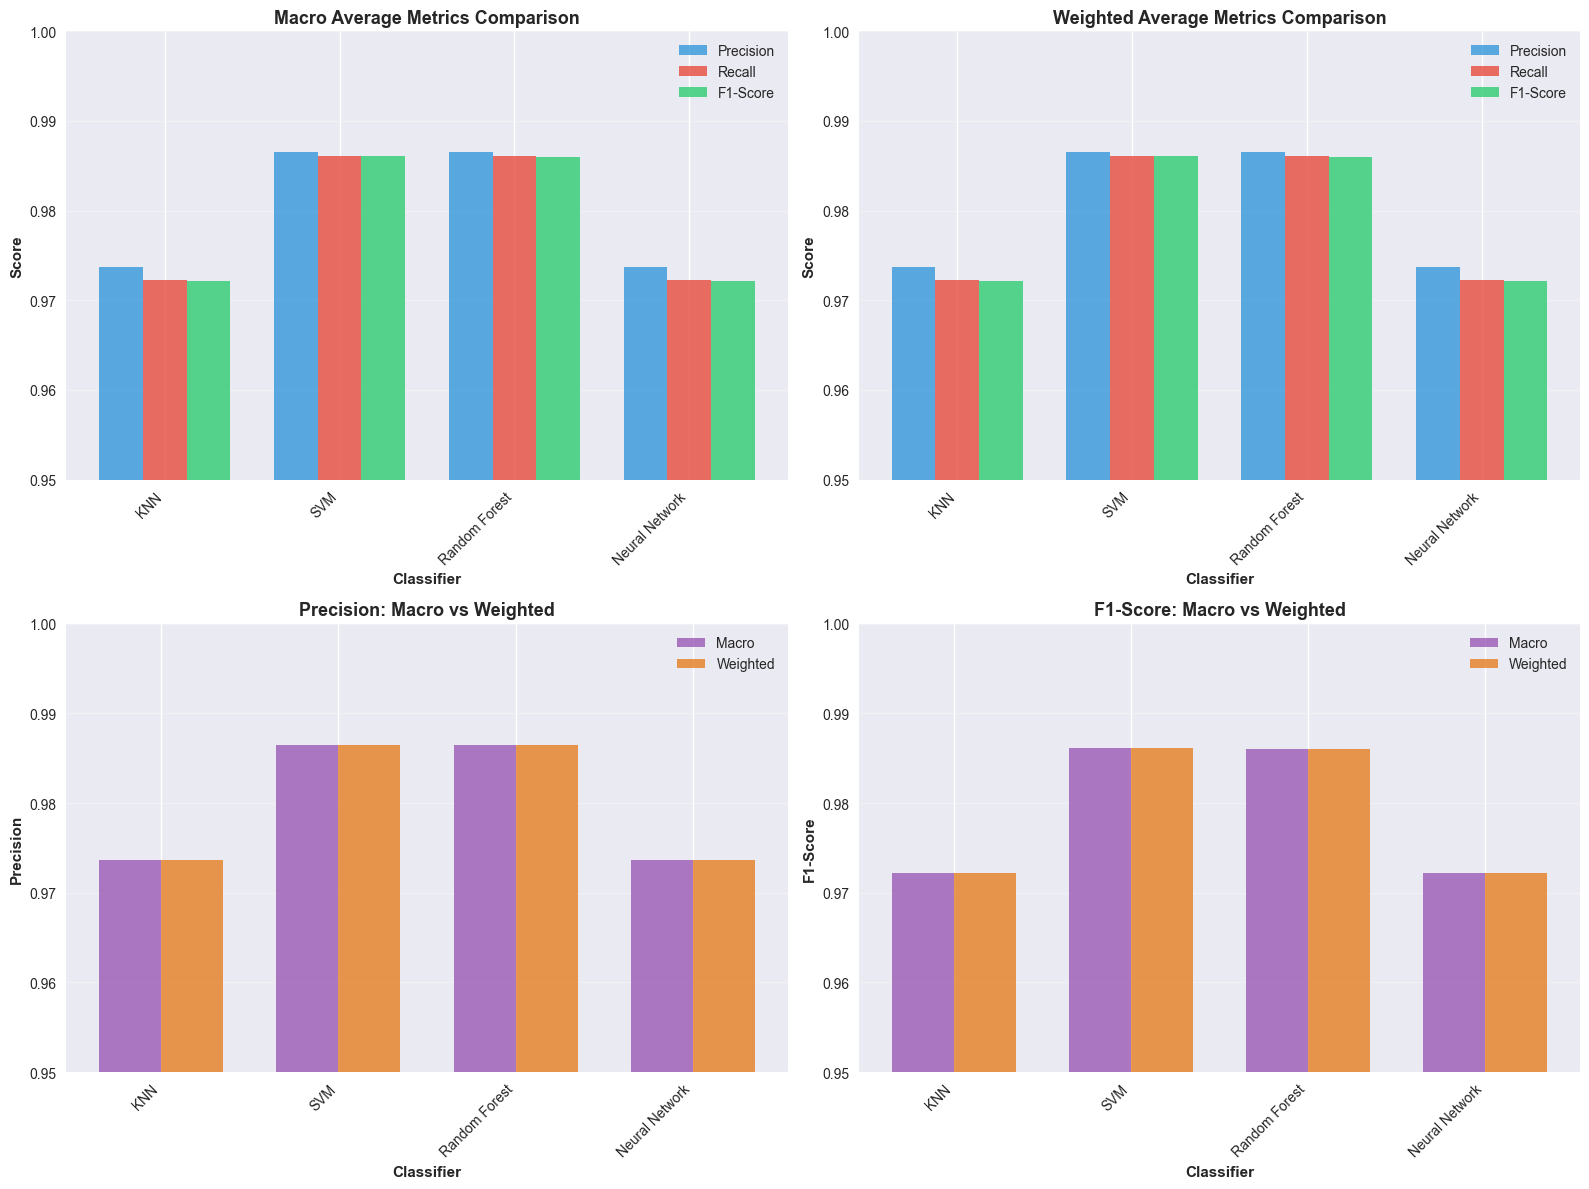

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
ylim = 0.95

ax1 = axes[0, 0]
x = np.arange(len(metrics_df))
width = 0.25
ax1.bar(x - width, metrics_df['Macro Precision'], width, label='Precision', color='#3498db', alpha=0.8)
ax1.bar(x, metrics_df['Macro Recall'], width, label='Recall', color='#e74c3c', alpha=0.8)
ax1.bar(x + width, metrics_df['Macro F1-Score'], width, label='F1-Score', color='#2ecc71', alpha=0.8)
ax1.set_xlabel('Classifier', fontsize=11, fontweight='bold')
ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
ax1.set_title('Macro Average Metrics Comparison', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_df['Classifier'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([ylim, 1])

ax2 = axes[0, 1]
ax2.bar(x - width, metrics_df['Weighted Precision'], width, label='Precision', color='#3498db', alpha=0.8)
ax2.bar(x, metrics_df['Weighted Recall'], width, label='Recall', color='#e74c3c', alpha=0.8)
ax2.bar(x + width, metrics_df['Weighted F1-Score'], width, label='F1-Score', color='#2ecc71', alpha=0.8)
ax2.set_xlabel('Classifier', fontsize=11, fontweight='bold')
ax2.set_ylabel('Score', fontsize=11, fontweight='bold')
ax2.set_title('Weighted Average Metrics Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_df['Classifier'], rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([ylim, 1])

ax3 = axes[1, 0]
x_pos = np.arange(len(metrics_df))
width = 0.35
ax3.bar(x_pos - width/2, metrics_df['Macro Precision'], width, label='Macro', color='#9b59b6', alpha=0.8)
ax3.bar(x_pos + width/2, metrics_df['Weighted Precision'], width, label='Weighted', color='#e67e22', alpha=0.8)
ax3.set_xlabel('Classifier', fontsize=11, fontweight='bold')
ax3.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax3.set_title('Precision: Macro vs Weighted', fontsize=13, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(metrics_df['Classifier'], rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)
ax3.set_ylim([ylim, 1])

ax4 = axes[1, 1]
ax4.bar(x_pos - width/2, metrics_df['Macro F1-Score'], width, label='Macro', color='#9b59b6', alpha=0.8)
ax4.bar(x_pos + width/2, metrics_df['Weighted F1-Score'], width, label='Weighted', color='#e67e22', alpha=0.8)
ax4.set_xlabel('Classifier', fontsize=11, fontweight='bold')
ax4.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
ax4.set_title('F1-Score: Macro vs Weighted', fontsize=13, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics_df['Classifier'], rotation=45, ha='right')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
ax4.set_ylim([ylim, 1])

plt.tight_layout()
plt.show()

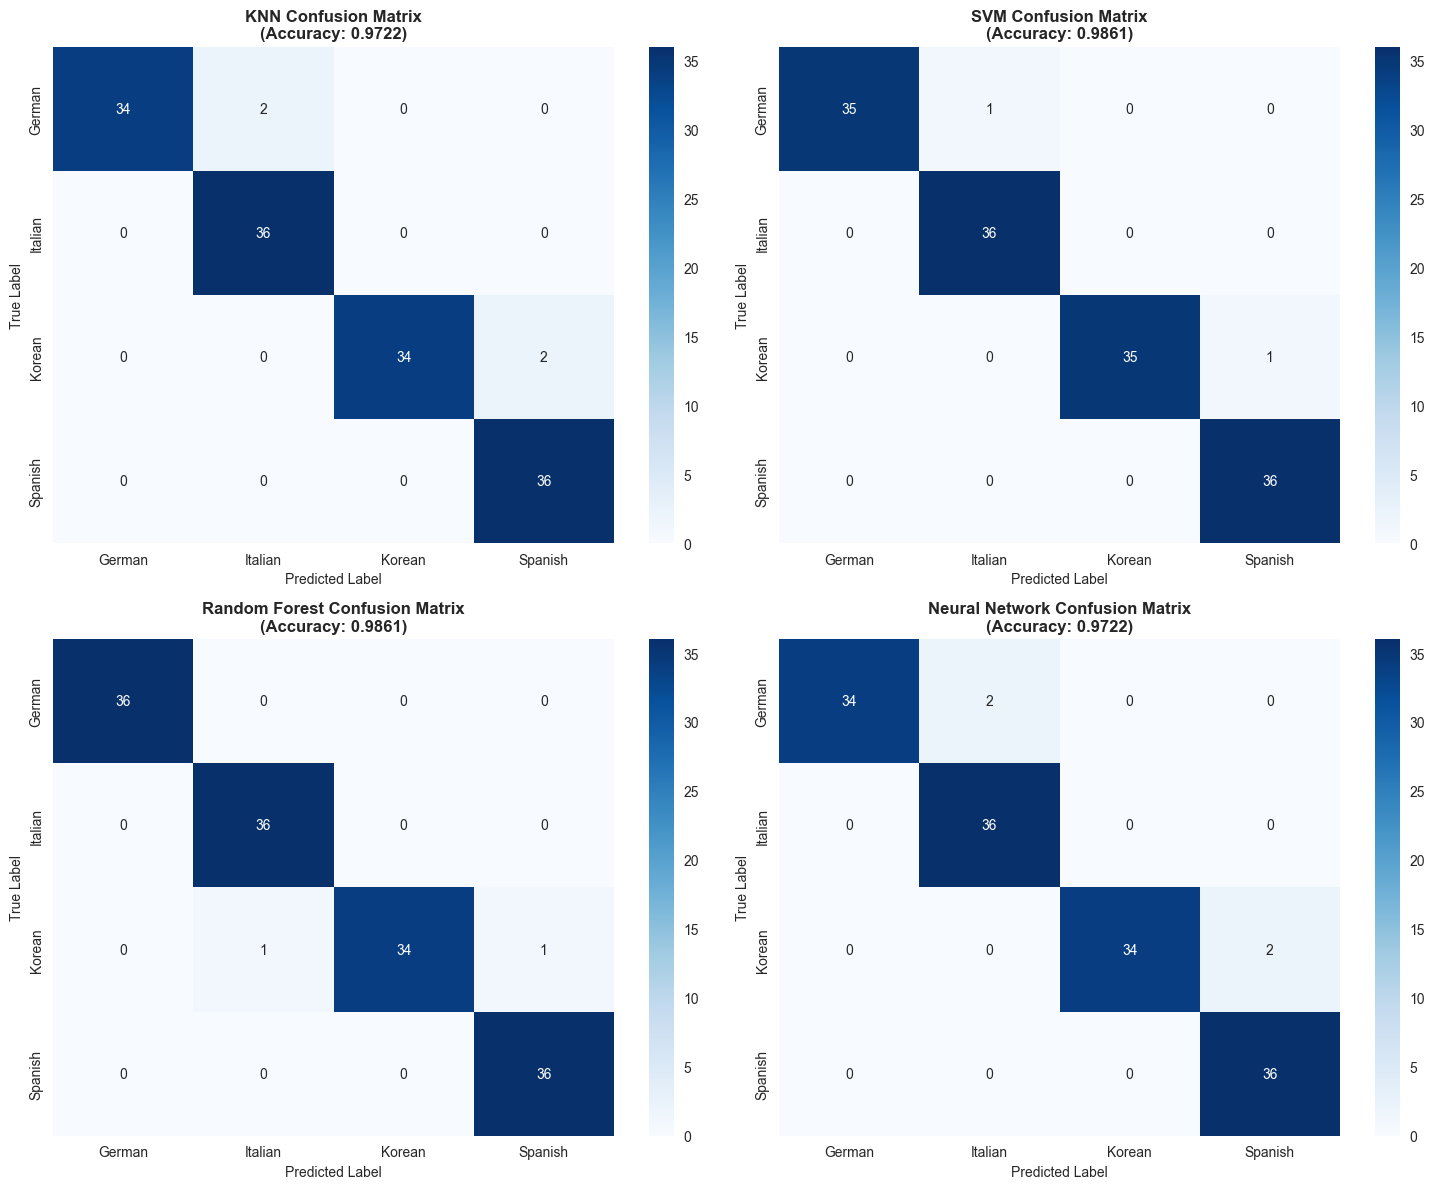

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

for idx, (name, result) in enumerate(results.items()):
    cm = result["confusion_matrix"]

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
        ax=axes[idx],
    )

    axes[idx].set_title(
        f'{name} Confusion Matrix\n(Accuracy: {result["accuracy"]:.4f})',
        fontsize=12,
        fontweight="bold",
    )
    axes[idx].set_xlabel("Predicted Label", fontsize=10)
    axes[idx].set_ylabel("True Label", fontsize=10)

plt.tight_layout()
plt.show()